Generating Final Decision Matrix...

Table VII Saved Successfully: 'table_7_decision_matrix.csv'
             Criterion Logistic Regression Random Forest   XGBoost      Selected Model
Predictive performance              Medium          High Very High             XGBoost
      Interpretability                High        Medium       Low Logistic Regression
            Robustness              Medium          High Very High             XGBoost
    Computational cost                 Low        Medium      High Logistic Regression
Deployment suitability                High          High    Medium       Random Forest

Generating Trade-off Radar Chart...
Figure 7 Saved Successfully: 'figure_7_tradeoff_analysis.pdf'


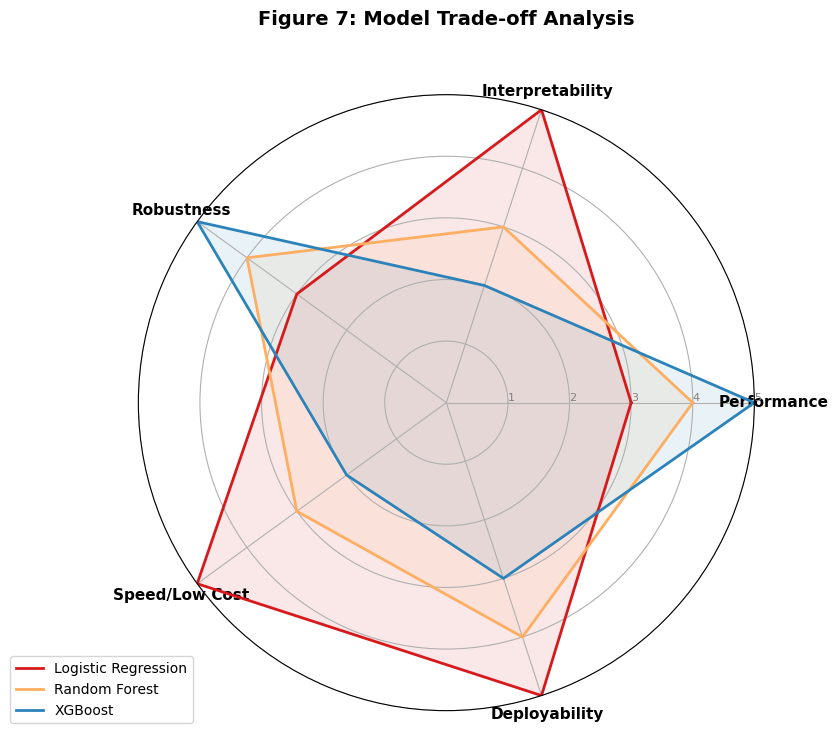

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi

# --- Generate Table VII: Conceptual Decision Matrix ---
print("Generating Final Decision Matrix...")

matrix_data = {
    'Criterion': ['Predictive performance', 'Interpretability', 'Robustness', 'Computational cost', 'Deployment suitability'],
    'Logistic Regression': ['Medium', 'High', 'Medium', 'Low', 'High'],
    'Random Forest': ['High', 'Medium', 'High', 'Medium', 'High'],
    'XGBoost': ['Very High', 'Low', 'Very High', 'High', 'Medium'],
    'Selected Model': ['XGBoost', 'Logistic Regression', 'XGBoost', 'Logistic Regression', 'Random Forest']
}

table_vii = pd.DataFrame(matrix_data)
table_vii.to_csv('table_7_decision_matrix.csv', index=False)
print("\nTable VII Saved Successfully: 'table_7_decision_matrix.csv'")
print(table_vii.to_string(index=False))

# --- Generate Figure 7: Radar Chart for Trade-off Analysis ---
print("\nGenerating Trade-off Radar Chart...")

# Convert conceptual text to 1-5 numerical scale for the radar chart
# 5 is "Best" (e.g., Very High performance = 5, Low computational cost = 5)
radar_data = pd.DataFrame({
    'Criterion': ['Performance', 'Interpretability', 'Robustness', 'Speed/Low Cost', 'Deployability'],
    'Logistic Regression': [3, 5, 3, 5, 5],
    'Random Forest': [4, 3, 4, 3, 4],
    'XGBoost': [5, 2, 5, 2, 3]
})

# Number of variables
categories = list(radar_data['Criterion'])
N = len(categories)

# What will be the angle of each axis in the plot? (divide the plot / number of variable)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1] # Repeat the first angle to close the circular graph

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

# Draw one axe per variable + add labels
plt.xticks(angles[:-1], categories, color='black', size=11, fontweight='bold')

# Draw ylabels
ax.set_rlabel_position(0)
plt.yticks([1, 2, 3, 4, 5], ["1", "2", "3", "4", "5"], color="grey", size=8)
plt.ylim(0, 5)

# Color palette
colors = ['#d7191c', '#fdae61', '#2b83ba']
models = ['Logistic Regression', 'Random Forest', 'XGBoost']

# Plot each model
for i, model in enumerate(models):
    values = radar_data[model].values.flatten().tolist()
    values += values[:1] # close the loop
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=model, color=colors[i])
    ax.fill(angles, values, color=colors[i], alpha=0.1)

# Add legend
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.title('Figure 7: Model Trade-off Analysis', size=14, fontweight='bold', y=1.1)

plt.savefig('figure_7_tradeoff_analysis.pdf', format='pdf', bbox_inches='tight')
print("Figure 7 Saved Successfully: 'figure_7_tradeoff_analysis.pdf'")

plt.show()